In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
%matplotlib inline
sns.set_style('whitegrid')

# Load the Titanic dataset
df = pd.read_csv('titanic.csv')

# Display the first 5 rows to confirm data loaded correctly
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Basic data exploration
print("Dataset shape:", df.shape)
print("\nData Types and Missing Values:")
df.info()

Dataset shape: (891, 12)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Survival Distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


/tmp/ipykernel_25117/4199507609.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


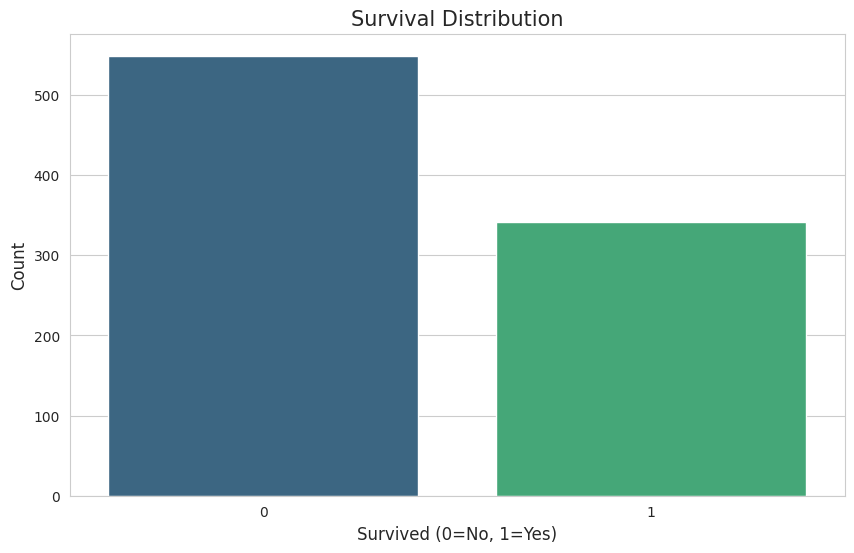

In [3]:
# Survival Distribution
print("Survival Distribution:")
print(df['Survived'].value_counts())
print("\nPercentage:")
print(df['Survived'].value_counts(normalize=True) * 100)

# Visualize survival
plt.figure(figsize=(10, 6))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Distribution', fontsize=15)
plt.xlabel('Survived (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

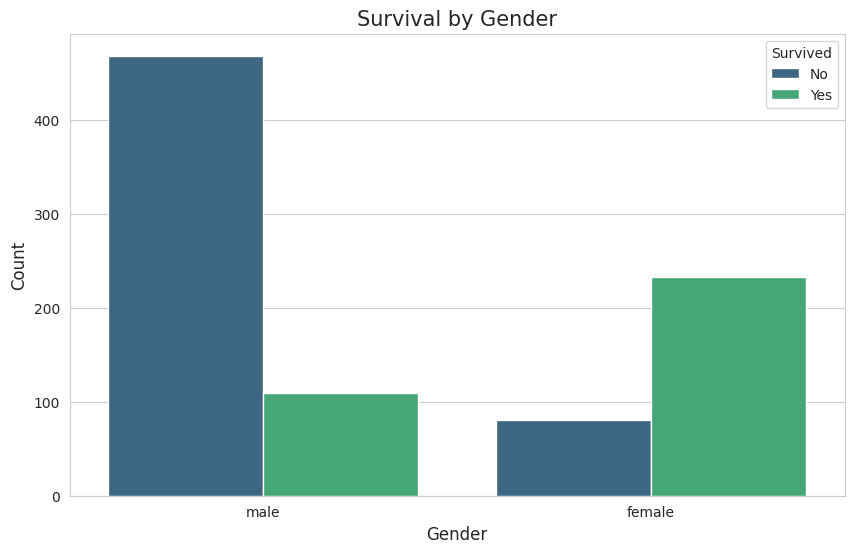

Male survival rate: 18.9%
Female survival rate: 74.2%


In [4]:
# Gender vs Survival
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# Calculate survival rates by gender
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100
print(f"Male survival rate: {survival_by_gender['male']:.1f}%")
print(f"Female survival rate: {survival_by_gender['female']:.1f}%")

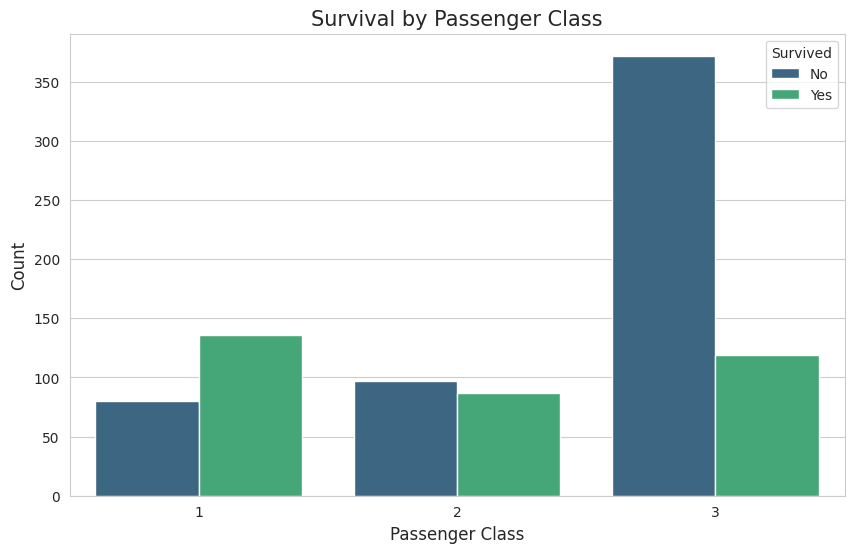

Class 1 survival rate: 63.0%
Class 2 survival rate: 47.3%
Class 3 survival rate: 24.2%


In [5]:
# Class vs Survival
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Passenger Class', fontsize=15)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# Calculate survival rates by class
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
for pclass in [1, 2, 3]:
    print(f"Class {pclass} survival rate: {survival_by_class[pclass]:.1f}%")